In [1]:
import subprocess, sys, os
os.system('pip install -q torch==2.1.2+cu118 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118')
os.system('pip uninstall -y bitsandbytes transformers accelerate peft sentence-transformers -q')
os.system('pip install -q bitsandbytes>=0.43.0 transformers>=4.40.0 accelerate>=0.27.0 peft>=0.10.0 sentencepiece sacremoses "sentence-transformers>=3.0.0" pandas numpy scikit-learn matplotlib datasets tqdm')

import ast, json, os, zipfile, warnings, time, gc, shutil, re, pickle, random
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from peft import PeftModel
warnings.filterwarnings('ignore')
print(f'PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}')

PyTorch: 2.11.0+cu128, CUDA: True


In [2]:
from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH = '/content/drive/MyDrive/semeval2025_task7_data.zip'
EXTRACT_DIR = '/content/semeval2025'
OUTPUT_DIR = '/content/drive/MyDrive/semeval_eng_hin_crosslingual_results'

if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)

def find_folder(root, target):
    for dirpath, dirnames, _ in os.walk(root):
        if target in dirnames:
            return os.path.join(dirpath, target)
    return None

TEST_SET_DIR = find_folder(EXTRACT_DIR, 'test_set')
print(f'TEST_SET_DIR: {TEST_SET_DIR}')

def read_csv_safely(path):
    return pd.read_csv(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TEST_SET_DIR: /content/semeval2025/test_set


In [3]:
def safe_parse_tuple(s):
    if pd.isna(s):
        return None
    try:
        return ast.literal_eval(s)
    except (ValueError, SyntaxError):
        return None

def extract_text(parsed, fallback=''):
    if parsed is None or len(parsed) < 2:
        return fallback
    text = parsed[1] if parsed[1] else parsed[0]
    return text if isinstance(text, str) else fallback

def get_ocr_fallback(ocr_str):
    parsed = safe_parse_tuple(ocr_str)
    if isinstance(parsed, list) and len(parsed) > 0:
        return extract_text(parsed[0])
    return ''

def build_fused_text(text_field_str, ocr_field_str):
    main_text = extract_text(safe_parse_tuple(text_field_str)).strip()
    ocr_text = get_ocr_fallback(ocr_field_str).strip()
    if not main_text and not ocr_text:
        return ''
    if not ocr_text:
        return main_text
    if not main_text:
        return ocr_text
    if ocr_text.lower() in main_text.lower():
        return main_text
    return f'{main_text} [OCR]: {ocr_text}'

In [4]:
test_fact_checks = read_csv_safely(os.path.join(TEST_SET_DIR, 'fact_checks.csv'))
test_posts       = read_csv_safely(os.path.join(TEST_SET_DIR, 'posts.csv'))
test_pairs_cross = read_csv_safely(os.path.join(TEST_SET_DIR, 'pairs_test_crosslingual.csv'))

with open(os.path.join(TEST_SET_DIR, 'tasks.json'), 'r', encoding='utf-8') as f:
    test_tasks = json.load(f)
with open(os.path.join(TEST_SET_DIR, 'crosslingual_reference.json'), 'r', encoding='utf-8') as f:
    crosslingual_reference = json.load(f)

cross_test_task = test_tasks['crosslingual']
cross_test_fact_check_ids = set(cross_test_task['fact_checks'])
cross_test_posts_ids      = set(cross_test_task['posts_test'])
print(f'TEST fact_checks pool: {len(cross_test_fact_check_ids)}, TEST posts: {len(cross_test_posts_ids)}')

TEST fact_checks pool: 272447, TEST posts: 4000


In [5]:
eng_test_posts_subset = test_posts[test_posts['post_id'].isin(cross_test_posts_ids)].copy()

def is_english_post(row):
    parsed = safe_parse_tuple(row['text'])
    if parsed is None or len(parsed) < 3:
        return False
    langs = parsed[2]
    if not isinstance(langs, list) or len(langs) == 0:
        return False
    if len(langs) == 2 and isinstance(langs[0], str) and isinstance(langs[1], (int, float)):
        dom = langs[0]
    else:
        try:
            dom = max(langs, key=lambda t: t[1])[0]
        except (TypeError, IndexError):
            dom = None
    return dom in {'eng', 'en'}

eng_test_posts_subset['is_english'] = eng_test_posts_subset.apply(is_english_post, axis=1)
eng_test_post_ids = set(eng_test_posts_subset.loc[eng_test_posts_subset['is_english'], 'post_id'])
print(f'English-detected TEST posts: {len(eng_test_post_ids)}')

English-detected TEST posts: 1003


In [6]:
test_claims_subset = test_fact_checks[test_fact_checks['fact_check_id'].isin(cross_test_fact_check_ids)].copy()

DEVANAGARI_RE = re.compile(r'[\u0900-\u097F]')
HINDI_LANG_CODES = {'hin', 'hi'}

def dominant_lang_from_langs_list(langs):
    if not isinstance(langs, list) or len(langs) == 0:
        return None
    if len(langs) == 2 and isinstance(langs[0], str) and isinstance(langs[1], (int, float)):
        return langs[0]
    try:
        return max(langs, key=lambda t: t[1])[0]
    except (TypeError, IndexError):
        return None

def is_hindi_claim(row):
    parsed = safe_parse_tuple(row['claim'])
    if parsed is None or len(parsed) < 1:
        return False
    original_text = parsed[0] if isinstance(parsed[0], str) else ''
    if original_text and DEVANAGARI_RE.search(original_text):
        return True
    if len(parsed) >= 3:
        dom = dominant_lang_from_langs_list(parsed[2])
        if dom in HINDI_LANG_CODES:
            return True
    return False

test_claims_subset['is_hindi'] = test_claims_subset.apply(is_hindi_claim, axis=1)
hin_test_claim_ids = set(test_claims_subset.loc[test_claims_subset['is_hindi'], 'fact_check_id'])
print(f'Hindi-detected TEST claims: {len(hin_test_claim_ids)}')

eng_hin_test_pairs = test_pairs_cross[
    test_pairs_cross['post_id'].isin(eng_test_post_ids) &
    test_pairs_cross['fact_check_id'].isin(hin_test_claim_ids)
].drop_duplicates().reset_index(drop=True)
print(f'eng->hin TEST pairs: {len(eng_hin_test_pairs)}')

Hindi-detected TEST claims: 11267
eng->hin TEST pairs: 170


In [7]:
test_fact_checks['claim_text'] = test_fact_checks['claim'].apply(lambda s: extract_text(safe_parse_tuple(s)))
test_claim_id_to_text = dict(zip(test_fact_checks['fact_check_id'], test_fact_checks['claim_text']))
test_claim_id_to_text = {k: v for k, v in test_claim_id_to_text.items() if k in cross_test_fact_check_ids and v.strip()}

eng_test_posts_df = test_posts[test_posts['post_id'].isin(eng_test_post_ids)].copy()
eng_test_posts_df['text_clean'] = eng_test_posts_df.apply(lambda row: build_fused_text(row['text'], row['ocr']), axis=1)
test_post_id_to_text = dict(zip(eng_test_posts_df['post_id'], eng_test_posts_df['text_clean']))
test_post_id_to_text = {k: v for k, v in test_post_id_to_text.items() if v.strip()}

eng_hin_test_post_ids = set(eng_hin_test_pairs['post_id'])
eng_hin_test_reference = {
    str(pid): [str(fc) for fc in fcs]
    for pid, fcs in crosslingual_reference.items()
    if int(pid) in eng_hin_test_post_ids
}
print(f'Claim texts: {len(test_claim_id_to_text)}, Post texts: {len(test_post_id_to_text)}, Ground truth: {len(eng_hin_test_reference)}')

Claim texts: 272447, Post texts: 1003, Ground truth: 160


In [8]:
def success_at_k(retrieved_ranked, ground_truth, k):
    hits = 0
    N = len(ground_truth)
    for pid, true_fcs in ground_truth.items():
        if pid not in retrieved_ranked:
            continue
        top_k = retrieved_ranked[pid][:k]
        if any(fc in true_fcs for fc in top_k):
            hits += 1
    return hits / N

def evaluate_all_k(retrieved_ranked, ground_truth, ks=(1, 5, 10)):
    results = {}
    for k in ks:
        score = success_at_k(retrieved_ranked, ground_truth, k)
        results[f'success@{k}'] = score
        print(f'success@{k}: {score:.4f}')
    return results

In [9]:
MODEL_NAME = 'intfloat/multilingual-e5-large'
MAX_LEN = 128
device = 'cuda' if torch.cuda.is_available() else 'cpu'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def mean_pool(last_hidden, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
    summed = torch.sum(last_hidden * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts

@torch.no_grad()
def encode_texts_eval(texts, prefix, model, batch_size=32):
    all_embs = []
    for i in tqdm(range(0, len(texts), batch_size), desc=f'Encoding ({prefix.strip(": ")})'):
        batch = [prefix + t for t in texts[i:i+batch_size]]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LEN, return_tensors='pt').to(device)
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            out = model(**enc)
            emb = mean_pool(out.last_hidden_state, enc['attention_mask'])
            emb = F.normalize(emb, p=2, dim=1)
        all_embs.append(emb.cpu())
        del enc, out, emb
    return torch.cat(all_embs, dim=0)

TOP_K_RETRIEVE = 10
test_claim_ids = list(test_claim_id_to_text.keys())
test_claim_texts = [test_claim_id_to_text[cid] for cid in test_claim_ids]
test_post_ids_list = [pid for pid in eng_hin_test_post_ids if pid in test_post_id_to_text]
test_post_texts_list = [test_post_id_to_text[pid] for pid in test_post_ids_list]

eval_output_dir = os.path.join(OUTPUT_DIR, 'evaluation_results_eng_hin')
with open(os.path.join(eval_output_dir, 'predictions_eng_hin_cross.json')) as f:
    retrieved_ranked = json.load(f)

print('\n=== Loaded SAVED fine-tuned result (no re-encoding needed) ===')
results_finetuned = evaluate_all_k(retrieved_ranked, eng_hin_test_reference, ks=(1, 5, 10))


=== Loaded SAVED fine-tuned result (no re-encoding needed) ===
success@1: 0.2062
success@5: 0.4875
success@10: 0.6188


In [10]:
frozen_model = AutoModel.from_pretrained(MODEL_NAME, dtype=torch.float16).to(device)
frozen_model.eval()

frozen_claim_embs = encode_texts_eval(test_claim_texts, prefix='passage: ', model=frozen_model)
frozen_post_embs  = encode_texts_eval(test_post_texts_list, prefix='query: ', model=frozen_model)

frozen_claim_embs_gpu = frozen_claim_embs.to(device).float()
frozen_retrieved_ranked = {}
for start in tqdm(range(0, len(test_post_ids_list), 128), desc='Retrieving (frozen)'):
    chunk_pids = test_post_ids_list[start:start+128]
    chunk_embs = frozen_post_embs[start:start+128].to(device).float()
    sims = chunk_embs @ frozen_claim_embs_gpu.T
    topk_idx = torch.topk(sims, k=TOP_K_RETRIEVE, dim=1).indices.cpu()
    for i, pid in enumerate(chunk_pids):
        frozen_retrieved_ranked[str(pid)] = [str(test_claim_ids[j]) for j in topk_idx[i].tolist()]
    del chunk_embs, sims, topk_idx
del frozen_claim_embs_gpu
torch.cuda.empty_cache()

print('\n=== FROZEN baseline ===')
results_frozen = evaluate_all_k(frozen_retrieved_ranked, eng_hin_test_reference, ks=(1, 5, 10))

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.24GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Retrieving (frozen): 100%|██████████| 2/2 [00:00<00:00, 21.18it/s]


=== FROZEN baseline ===
success@1: 0.1812
success@5: 0.5125
success@10: 0.6375


In [11]:
from collections import defaultdict

def reciprocal_rank_fusion(rank_lists, k=60):
    scores = defaultdict(float)
    for ranked in rank_lists:
        for rank, cid in enumerate(ranked):
            scores[cid] += 1.0 / (k + rank + 1)
    return sorted(scores, key=lambda c: -scores[c])

fused_retrieved_ranked = {}
for pid in test_post_ids_list:
    pid_str = str(pid)
    lists = [l for l in (retrieved_ranked.get(pid_str), frozen_retrieved_ranked.get(pid_str)) if l]
    fused_retrieved_ranked[pid_str] = reciprocal_rank_fusion(lists)[:TOP_K_RETRIEVE]

print('\n=== FUSED result ===')
results_fused = evaluate_all_k(fused_retrieved_ranked, eng_hin_test_reference, ks=(1, 5, 10))


=== FUSED result ===
success@1: 0.1938
success@5: 0.5000
success@10: 0.6375


In [1]:
import os
os.system('pip install -q torch==2.1.2+cu118 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118')
os.system('pip uninstall -y bitsandbytes transformers accelerate peft sentence-transformers -q')
os.system('pip install -q bitsandbytes>=0.43.0 transformers>=4.40.0 accelerate>=0.27.0 peft>=0.10.0 sentencepiece sacremoses "sentence-transformers>=3.0.0" pandas numpy scikit-learn matplotlib datasets tqdm')

import ast, json, os, zipfile, warnings, time, gc, shutil, re, pickle, random
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn.functional as F
warnings.filterwarnings('ignore')
print(f'PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}')

PyTorch: 2.11.0+cu128, CUDA: True


In [2]:
from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH = '/content/drive/MyDrive/semeval2025_task7_data.zip'
EXTRACT_DIR = '/content/semeval2025'
OUTPUT_DIR = '/content/drive/MyDrive/semeval_eng_hin_crosslingual_results'

if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)

def find_folder(root, target):
    for dirpath, dirnames, _ in os.walk(root):
        if target in dirnames:
            return os.path.join(dirpath, target)
    return None

TRAIN_DEV_DIR = find_folder(EXTRACT_DIR, 'train_dev_sets')
TEST_SET_DIR  = find_folder(EXTRACT_DIR, 'test_set')
print(f'TRAIN_DEV_DIR: {TRAIN_DEV_DIR}')
print(f'TEST_SET_DIR: {TEST_SET_DIR}')

def read_csv_safely(path):
    return pd.read_csv(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TRAIN_DEV_DIR: /content/semeval2025/train_dev_sets
TEST_SET_DIR: /content/semeval2025/test_set


In [3]:
fact_checks = read_csv_safely(os.path.join(TRAIN_DEV_DIR, 'fact_checks.csv'))
posts       = read_csv_safely(os.path.join(TRAIN_DEV_DIR, 'posts.csv'))
pairs_train_all = read_csv_safely(os.path.join(TRAIN_DEV_DIR, 'pairs.csv'))

with open(os.path.join(TRAIN_DEV_DIR, 'tasks.json'), 'r', encoding='utf-8') as f:
    tasks = json.load(f)

LANG = 'eng'
eng_task = tasks['monolingual'][LANG]
eng_fact_check_ids  = set(eng_task['fact_checks'])
eng_posts_train_ids = set(eng_task['posts_train'])

eng_train_pairs = pairs_train_all[
    pairs_train_all['post_id'].isin(eng_posts_train_ids) &
    pairs_train_all['fact_check_id'].isin(eng_fact_check_ids)
].drop_duplicates().reset_index(drop=True)
print(f'eng-eng TRAIN pairs: {len(eng_train_pairs)}')

eng-eng TRAIN pairs: 5446


In [4]:
def safe_parse_tuple(s):
    if pd.isna(s):
        return None
    try:
        return ast.literal_eval(s)
    except (ValueError, SyntaxError):
        return None

def extract_text(parsed, fallback=''):
    if parsed is None or len(parsed) < 2:
        return fallback
    text = parsed[1] if parsed[1] else parsed[0]
    return text if isinstance(text, str) else fallback

def get_ocr_fallback(ocr_str):
    parsed = safe_parse_tuple(ocr_str)
    if isinstance(parsed, list) and len(parsed) > 0:
        return extract_text(parsed[0])
    return ''

def build_fused_text(text_field_str, ocr_field_str):
    main_text = extract_text(safe_parse_tuple(text_field_str)).strip()
    ocr_text = get_ocr_fallback(ocr_field_str).strip()
    if not main_text and not ocr_text:
        return ''
    if not ocr_text:
        return main_text
    if not main_text:
        return ocr_text
    if ocr_text.lower() in main_text.lower():
        return main_text
    return f'{main_text} [OCR]: {ocr_text}'

eng_posts_train_df = posts[posts['post_id'].isin(eng_posts_train_ids)].copy()
eng_posts_train_df['text_clean'] = eng_posts_train_df.apply(lambda row: build_fused_text(row['text'], row['ocr']), axis=1)
post_id_to_text = dict(zip(eng_posts_train_df['post_id'], eng_posts_train_df['text_clean']))
post_id_to_text = {k: v for k, v in post_id_to_text.items() if v.strip()}

eng_claims_pool_df = fact_checks[fact_checks['fact_check_id'].isin(eng_fact_check_ids)].copy()
eng_claims_pool_df['claim_text'] = eng_claims_pool_df['claim'].apply(lambda s: extract_text(safe_parse_tuple(s)))
claim_id_to_text_eng = dict(zip(eng_claims_pool_df['fact_check_id'], eng_claims_pool_df['claim_text']))
claim_id_to_text_eng = {k: v for k, v in claim_id_to_text_eng.items() if v.strip()}

usable_pairs = eng_train_pairs[
    eng_train_pairs['post_id'].isin(post_id_to_text.keys()) &
    eng_train_pairs['fact_check_id'].isin(claim_id_to_text_eng.keys())
].drop_duplicates().reset_index(drop=True)
print(f'Usable eng-eng pairs: {len(usable_pairs)}')

Usable eng-eng pairs: 5446


In [5]:
random.seed(123)
real_dev_pairs = usable_pairs.sample(n=min(200, len(usable_pairs)), random_state=123)

real_dev_pool_df = eng_claims_pool_df.sample(n=min(3000, len(eng_claims_pool_df)), random_state=123)
real_dev_pool_ids = set(real_dev_pool_df['fact_check_id']) | set(real_dev_pairs['fact_check_id'])
real_dev_pool_texts_map = {cid: claim_id_to_text_eng[cid] for cid in real_dev_pool_ids if cid in claim_id_to_text_eng}
real_dev_pool_ids = list(real_dev_pool_texts_map.keys())
real_dev_pool_texts = [real_dev_pool_texts_map[c] for c in real_dev_pool_ids]

real_dev_rows = [(p, c) for p, c in zip(real_dev_pairs['post_id'], real_dev_pairs['fact_check_id']) if p in post_id_to_text]
real_dev_queries = [post_id_to_text[p] for p, c in real_dev_rows]
real_dev_truth_ids = [c for p, c in real_dev_rows]
print(f'Real-text dev set: {len(real_dev_queries)} queries over pool of {len(real_dev_pool_texts)}')

Real-text dev set: 200 queries over pool of 3184


In [6]:
with open(os.path.join(OUTPUT_DIR, 'train_examples_eng_hin_synth.pkl'), 'rb') as f:
    train_examples = pickle.load(f)
print(f'Loaded {len(train_examples)} raw train examples')

DEVANAGARI_RE = re.compile(r'[\u0900-\u097F]')

def devanagari_ratio(text):
    if not text:
        return 0
    dev_chars = len(DEVANAGARI_RE.findall(text))
    return dev_chars / max(len(text), 1)

train_examples_filtered = [ex for ex in train_examples if devanagari_ratio(ex['positive']) > 0.3]
print(f'{len(train_examples_filtered)} / {len(train_examples)} pairs kept after quality filter')

Loaded 4902 raw train examples
4902 / 4902 pairs kept after quality filter


In [7]:
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = 'intfloat/multilingual-e5-large'
MAX_LEN = 128
device = 'cuda' if torch.cuda.is_available() else 'cpu'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def mean_pool(last_hidden, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
    summed = torch.sum(last_hidden * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts

In [8]:
from transformers import BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

lora_config = LoraConfig(
    r=16,                                        # was 8
    lora_alpha=32,                                # keep alpha = 2x rank ratio
    target_modules=['query', 'key', 'value', 'dense'],  # added dense
    lora_dropout=0.2,
    bias='none',
    task_type='FEATURE_EXTRACTION',
)
print('QLoRA config: rank=16, wider target modules.')

QLoRA config: rank=16, wider target modules.


In [9]:
from torch.utils.data import Dataset, DataLoader

BATCH_SIZE = 16
GRAD_ACCUM_STEPS = 2
EPOCHS = 2
LR = 8e-6                # lower than before since capacity is higher now
TEMPERATURE = 0.05
WARMUP_RATIO = 0.1
N_NEGS_PER_STEP = 3

class TripletDataset(Dataset):
    def __init__(self, examples): self.examples = examples
    def __len__(self): return len(self.examples)
    def __getitem__(self, idx):
        ex = self.examples[idx]
        negs = ex['negatives']
        if len(negs) >= N_NEGS_PER_STEP:
            chosen = random.sample(negs, N_NEGS_PER_STEP)
        else:
            chosen = [random.choice(negs) for _ in range(N_NEGS_PER_STEP)]
        return ex['query'], ex['positive'], chosen

def collate_fn(batch):
    queries, positives, negs_lists = zip(*batch)
    flat_negatives = [n for negs in negs_lists for n in negs]
    return list(queries), list(positives), flat_negatives

train_ds = TripletDataset(train_examples_filtered)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

def encode_batch(texts, prefix, model, tokenizer, max_len=MAX_LEN):
    batch = [prefix + t for t in texts]
    enc = tokenizer(batch, padding=True, truncation=True, max_length=max_len, return_tensors='pt').to(device)
    out = model(**enc)
    emb = mean_pool(out.last_hidden_state, enc['attention_mask'])
    return F.normalize(emb, p=2, dim=1)

print(f'DataLoader ready: {len(train_ds)} filtered examples')

DataLoader ready: 4902 filtered examples


In [10]:
from datetime import datetime

CKPT_DIR = os.path.join(OUTPUT_DIR, 'training_checkpoint_eng_hin_v2')
os.makedirs(CKPT_DIR, exist_ok=True)

def save_checkpoint(model, optimizer, epoch, step, global_step, avg_loss, best_dev=None):
    model.save_pretrained(os.path.join(CKPT_DIR, 'adapter'))
    torch.save(optimizer.state_dict(), os.path.join(CKPT_DIR, 'optimizer.pt'))
    state = {'epoch': epoch, 'step_in_epoch': step, 'global_step': global_step,
              'avg_loss_so_far': avg_loss, 'best_pseudo_dev': best_dev,
              'timestamp': datetime.now().isoformat()}
    with open(os.path.join(CKPT_DIR, 'trainer_state.json'), 'w') as f:
        json.dump(state, f, indent=2)
    print(f'💾 Checkpoint saved | epoch={epoch} step={step} global_step={global_step} loss={avg_loss:.4f}')

def load_checkpoint_if_exists():
    state_path = os.path.join(CKPT_DIR, 'trainer_state.json')
    if not os.path.exists(state_path):
        print('No checkpoint found — starting fresh.')
        return None
    with open(state_path, 'r') as f:
        state = json.load(f)
    print(f"✅ Found checkpoint: epoch={state['epoch']}, step={state['step_in_epoch']}")
    return state

In [11]:
from peft import PeftModel
from torch.optim import AdamW

checkpoint_state = load_checkpoint_if_exists()
adapter_path = os.path.join(CKPT_DIR, 'adapter')

if checkpoint_state is not None and os.path.exists(adapter_path):
    model_4bit = AutoModel.from_pretrained(MODEL_NAME, quantization_config=bnb_config, device_map={'': 0})
    model_4bit = prepare_model_for_kbit_training(model_4bit)
    model = PeftModel.from_pretrained(model_4bit, adapter_path, is_trainable=True)
else:
    model_4bit = AutoModel.from_pretrained(MODEL_NAME, quantization_config=bnb_config, device_map={'': 0})
    model_4bit = prepare_model_for_kbit_training(model_4bit)
    model = get_peft_model(model_4bit, lora_config)

model.print_trainable_parameters()
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

optimizer_path = os.path.join(CKPT_DIR, 'optimizer.pt')
if checkpoint_state is not None and os.path.exists(optimizer_path):
    optimizer.load_state_dict(torch.load(optimizer_path, map_location=device))

start_epoch = checkpoint_state['epoch'] if checkpoint_state else 0
start_step_in_epoch = checkpoint_state['step_in_epoch'] if checkpoint_state else 0
global_step = checkpoint_state['global_step'] if checkpoint_state else 0
best_pseudo_dev = checkpoint_state.get('best_pseudo_dev') if checkpoint_state else None

No checkpoint found — starting fresh.


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

trainable params: 7,110,656 || all params: 567,001,088 || trainable%: 1.2541


In [12]:
from transformers import get_linear_schedule_with_warmup

SAVE_EVERY_STEPS = 100
total_steps = (len(train_loader) // GRAD_ACCUM_STEPS) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(total_steps * WARMUP_RATIO), num_training_steps=total_steps)

@torch.no_grad()
def quick_real_dev_eval(model):
    model.eval()
    def _enc(texts, prefix):
        embs = []
        for i in range(0, len(texts), 32):
            batch = [prefix + t for t in texts[i:i+32]]
            enc = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LEN, return_tensors='pt').to(device)
            out = model(**enc)
            emb = mean_pool(out.last_hidden_state, enc['attention_mask'])
            embs.append(F.normalize(emb, p=2, dim=1).cpu())
        return torch.cat(embs, dim=0)
    q_embs = _enc(real_dev_queries, 'query: ')
    c_embs = _enc(real_dev_pool_texts, 'passage: ')
    sims = q_embs.float() @ c_embs.float().T
    topk = torch.topk(sims, k=10, dim=1).indices
    hits10 = sum(1 for i in range(len(real_dev_queries)) if real_dev_truth_ids[i] in [real_dev_pool_ids[j] for j in topk[i].tolist()])
    score = hits10 / len(real_dev_queries)
    model.train()
    del q_embs, c_embs, sims, topk
    torch.cuda.empty_cache()
    return score

model.train()
running_loss = 0.0
step_count = 0

for epoch in range(start_epoch, EPOCHS):
    for step, (queries, positives, negatives) in enumerate(train_loader):
        if epoch == start_epoch and step < start_step_in_epoch:
            continue
        q_emb = encode_batch(queries, 'query: ', model, tokenizer)
        p_emb = encode_batch(positives, 'passage: ', model, tokenizer)
        n_emb = encode_batch(negatives, 'passage: ', model, tokenizer)
        candidates = torch.cat([p_emb, n_emb], dim=0)
        logits = q_emb @ candidates.T / TEMPERATURE
        labels = torch.arange(len(queries), device=device)
        loss = F.cross_entropy(logits, labels) / GRAD_ACCUM_STEPS
        loss.backward()
        running_loss += loss.item()

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            global_step += 1
            step_count += 1

            if global_step % SAVE_EVERY_STEPS == 0:
                avg_loss = running_loss / max(step_count, 1)
                real_dev_score = quick_real_dev_eval(model)
                print(f'[epoch {epoch} step {step}] loss={avg_loss:.4f} real_dev_success@10={real_dev_score:.4f}')
                is_best = best_pseudo_dev is None or real_dev_score > best_pseudo_dev
                if is_best:
                    best_pseudo_dev = real_dev_score
                    model.save_pretrained(os.path.join(OUTPUT_DIR, 'lora_best_real_dev_v2'))
                    print(f'  ⭐ New best real-dev score')
                else:
                    print(f'  (not better than best={best_pseudo_dev:.4f})')
                save_checkpoint(model, optimizer, epoch, step + 1, global_step, avg_loss, best_pseudo_dev)
                running_loss, step_count = 0.0, 0
        del q_emb, p_emb, n_emb, candidates, logits
    start_step_in_epoch = 0

save_checkpoint(model, optimizer, EPOCHS, 0, global_step, running_loss / max(step_count, 1), best_pseudo_dev)
print(f'\n✅ Training complete. Best real-dev success@10: {best_pseudo_dev:.4f}')

[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


[epoch 0 step 199] loss=2.8379 real_dev_success@10=0.9150
  ⭐ New best real-dev score
💾 Checkpoint saved | epoch=0 step=200 global_step=100 loss=2.8379
[epoch 1 step 93] loss=1.4894 real_dev_success@10=0.9250
  ⭐ New best real-dev score
💾 Checkpoint saved | epoch=1 step=94 global_step=200 loss=1.4894
[epoch 1 step 293] loss=0.8117 real_dev_success@10=0.9250
  (not better than best=0.9250)
💾 Checkpoint saved | epoch=1 step=294 global_step=300 loss=0.8117
💾 Checkpoint saved | epoch=2 step=0 global_step=306 loss=0.7069

✅ Training complete. Best real-dev success@10: 0.9250


In [13]:
test_fact_checks = read_csv_safely(os.path.join(TEST_SET_DIR, 'fact_checks.csv'))
test_posts       = read_csv_safely(os.path.join(TEST_SET_DIR, 'posts.csv'))
test_pairs_cross = read_csv_safely(os.path.join(TEST_SET_DIR, 'pairs_test_crosslingual.csv'))

with open(os.path.join(TEST_SET_DIR, 'tasks.json'), 'r', encoding='utf-8') as f:
    test_tasks = json.load(f)
with open(os.path.join(TEST_SET_DIR, 'crosslingual_reference.json'), 'r', encoding='utf-8') as f:
    crosslingual_reference = json.load(f)

cross_test_task = test_tasks['crosslingual']
cross_test_fact_check_ids = set(cross_test_task['fact_checks'])
cross_test_posts_ids      = set(cross_test_task['posts_test'])

eng_test_posts_subset = test_posts[test_posts['post_id'].isin(cross_test_posts_ids)].copy()

def is_english_post(row):
    parsed = safe_parse_tuple(row['text'])
    if parsed is None or len(parsed) < 3:
        return False
    langs = parsed[2]
    if not isinstance(langs, list) or len(langs) == 0:
        return False
    if len(langs) == 2 and isinstance(langs[0], str) and isinstance(langs[1], (int, float)):
        dom = langs[0]
    else:
        try:
            dom = max(langs, key=lambda t: t[1])[0]
        except (TypeError, IndexError):
            dom = None
    return dom in {'eng', 'en'}

eng_test_posts_subset['is_english'] = eng_test_posts_subset.apply(is_english_post, axis=1)
eng_test_post_ids = set(eng_test_posts_subset.loc[eng_test_posts_subset['is_english'], 'post_id'])

test_claims_subset = test_fact_checks[test_fact_checks['fact_check_id'].isin(cross_test_fact_check_ids)].copy()
HINDI_LANG_CODES = {'hin', 'hi'}

def dominant_lang_from_langs_list(langs):
    if not isinstance(langs, list) or len(langs) == 0:
        return None
    if len(langs) == 2 and isinstance(langs[0], str) and isinstance(langs[1], (int, float)):
        return langs[0]
    try:
        return max(langs, key=lambda t: t[1])[0]
    except (TypeError, IndexError):
        return None

def is_hindi_claim(row):
    parsed = safe_parse_tuple(row['claim'])
    if parsed is None or len(parsed) < 1:
        return False
    original_text = parsed[0] if isinstance(parsed[0], str) else ''
    if original_text and DEVANAGARI_RE.search(original_text):
        return True
    if len(parsed) >= 3:
        dom = dominant_lang_from_langs_list(parsed[2])
        if dom in HINDI_LANG_CODES:
            return True
    return False

test_claims_subset['is_hindi'] = test_claims_subset.apply(is_hindi_claim, axis=1)
hin_test_claim_ids = set(test_claims_subset.loc[test_claims_subset['is_hindi'], 'fact_check_id'])

eng_hin_test_pairs = test_pairs_cross[
    test_pairs_cross['post_id'].isin(eng_test_post_ids) &
    test_pairs_cross['fact_check_id'].isin(hin_test_claim_ids)
].drop_duplicates().reset_index(drop=True)
print(f'eng->hin TEST pairs: {len(eng_hin_test_pairs)}')

test_fact_checks['claim_text'] = test_fact_checks['claim'].apply(lambda s: extract_text(safe_parse_tuple(s)))
test_claim_id_to_text = dict(zip(test_fact_checks['fact_check_id'], test_fact_checks['claim_text']))
test_claim_id_to_text = {k: v for k, v in test_claim_id_to_text.items() if k in cross_test_fact_check_ids and v.strip()}

eng_test_posts_df = test_posts[test_posts['post_id'].isin(eng_test_post_ids)].copy()
eng_test_posts_df['text_clean'] = eng_test_posts_df.apply(lambda row: build_fused_text(row['text'], row['ocr']), axis=1)
test_post_id_to_text = dict(zip(eng_test_posts_df['post_id'], eng_test_posts_df['text_clean']))
test_post_id_to_text = {k: v for k, v in test_post_id_to_text.items() if v.strip()}

eng_hin_test_post_ids = set(eng_hin_test_pairs['post_id'])
eng_hin_test_reference = {
    str(pid): [str(fc) for fc in fcs]
    for pid, fcs in crosslingual_reference.items()
    if int(pid) in eng_hin_test_post_ids
}
print(f'Ground truth: {len(eng_hin_test_reference)}')

eng->hin TEST pairs: 170
Ground truth: 160


In [14]:
def success_at_k(retrieved_ranked, ground_truth, k):
    hits = 0
    N = len(ground_truth)
    for pid, true_fcs in ground_truth.items():
        if pid not in retrieved_ranked:
            continue
        top_k = retrieved_ranked[pid][:k]
        if any(fc in true_fcs for fc in top_k):
            hits += 1
    return hits / N

def evaluate_all_k(retrieved_ranked, ground_truth, ks=(1, 5, 10)):
    results = {}
    for k in ks:
        score = success_at_k(retrieved_ranked, ground_truth, k)
        results[f'success@{k}'] = score
        print(f'success@{k}: {score:.4f}')
    return results

In [15]:
from transformers import BitsAndBytesConfig
from peft import PeftModel

bnb_config_eval = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True,
)

for var in ['eval_base_model', 'eval_model']:
    if var in globals():
        del globals()[var]
gc.collect()
torch.cuda.empty_cache()

FINAL_ADAPTER_PATH = os.path.join(OUTPUT_DIR, 'lora_best_real_dev_v2')
eval_base_model = AutoModel.from_pretrained(MODEL_NAME, quantization_config=bnb_config_eval, device_map={'': 0})
eval_model = PeftModel.from_pretrained(eval_base_model, FINAL_ADAPTER_PATH)
eval_model.eval()

@torch.no_grad()
def encode_texts_eval(texts, prefix, model, batch_size=32):
    all_embs = []
    for i in tqdm(range(0, len(texts), batch_size), desc=f'Encoding ({prefix.strip(": ")})'):
        batch = [prefix + t for t in texts[i:i+batch_size]]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LEN, return_tensors='pt').to(device)
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            out = model(**enc)
            emb = mean_pool(out.last_hidden_state, enc['attention_mask'])
            emb = F.normalize(emb, p=2, dim=1)
        all_embs.append(emb.cpu())
        del enc, out, emb
    return torch.cat(all_embs, dim=0)

TOP_K_RETRIEVE = 10
test_claim_ids = list(test_claim_id_to_text.keys())
test_claim_texts = [test_claim_id_to_text[cid] for cid in test_claim_ids]
test_post_ids_list = [pid for pid in eng_hin_test_post_ids if pid in test_post_id_to_text]
test_post_texts_list = [test_post_id_to_text[pid] for pid in test_post_ids_list]

test_claim_embs = encode_texts_eval(test_claim_texts, prefix='passage: ', model=eval_model)
test_post_embs  = encode_texts_eval(test_post_texts_list, prefix='query: ', model=eval_model)

test_claim_embs_gpu = test_claim_embs.to(device).float()
retrieved_ranked_v2 = {}
for start in tqdm(range(0, len(test_post_ids_list), 128), desc='Retrieving top-10'):
    chunk_pids = test_post_ids_list[start:start+128]
    chunk_embs = test_post_embs[start:start+128].to(device).float()
    sims = chunk_embs @ test_claim_embs_gpu.T
    topk_idx = torch.topk(sims, k=TOP_K_RETRIEVE, dim=1).indices.cpu()
    for i, pid in enumerate(chunk_pids):
        retrieved_ranked_v2[str(pid)] = [str(test_claim_ids[j]) for j in topk_idx[i].tolist()]
    del chunk_embs, sims, topk_idx
del test_claim_embs_gpu
torch.cuda.empty_cache()

print('\n=== Fine-tuned v2 (rank-16, filtered translations) — REAL eng->hin TEST result ===')
results_finetuned_v2 = evaluate_all_k(retrieved_ranked_v2, eng_hin_test_reference, ks=(1, 5, 10))

eval_output_dir = os.path.join(OUTPUT_DIR, 'evaluation_results_eng_hin')
with open(os.path.join(eval_output_dir, 'predictions_eng_hin_cross_v2.json'), 'w') as f:
    json.dump(retrieved_ranked_v2, f, indent=2)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Retrieving top-10: 100%|██████████| 2/2 [00:00<00:00, 23.55it/s]


=== Fine-tuned v2 (rank-16, filtered translations) — REAL eng->hin TEST result ===
success@1: 0.1500
success@5: 0.4250
success@10: 0.5437


In [11]:
def find_folder(root, target):
    for dirpath, dirnames, _ in os.walk(root):
        if target in dirnames:
            return os.path.join(dirpath, target)
    return None

TRAIN_DEV_DIR = find_folder(EXTRACT_DIR, 'train_dev_sets')
print(f'TRAIN_DEV_DIR: {TRAIN_DEV_DIR}')

TRAIN_DEV_DIR: /content/semeval2025/train_dev_sets


In [12]:
with open(os.path.join(OUTPUT_DIR, 'pseudo_dev_pairs.pkl'), 'rb') as f:
    pseudo_dev_pairs = pickle.load(f)
with open(os.path.join(OUTPUT_DIR, 'train_examples_eng_hin_synth.pkl'), 'rb') as f:
    train_examples = pickle.load(f)

print(f'Held-out dev pairs (never used in training): {len(pseudo_dev_pairs)}')

# Rebuild fact_checks + tasks to get REAL natural-language crosslingual claims as distractors
fact_checks = read_csv_safely(os.path.join(TRAIN_DEV_DIR, 'fact_checks.csv'))
with open(os.path.join(TRAIN_DEV_DIR, 'tasks.json'), 'r', encoding='utf-8') as f:
    tasks = json.load(f)

cross_task = tasks['crosslingual']
cross_fact_check_ids = set(cross_task['fact_checks'])
cross_claims_pool_df = fact_checks[fact_checks['fact_check_id'].isin(cross_fact_check_ids)].copy()
cross_claims_pool_df['claim_text'] = cross_claims_pool_df['claim'].apply(lambda s: extract_text(safe_parse_tuple(s)))
neg_pool_id_to_text = dict(zip(cross_claims_pool_df['fact_check_id'], cross_claims_pool_df['claim_text']))
neg_pool_id_to_text = {k: v for k, v in neg_pool_id_to_text.items() if v.strip()}

random.seed(7)
real_distractor_ids = random.sample(list(neg_pool_id_to_text.keys()), min(3000, len(neg_pool_id_to_text)))
real_distractor_texts = [neg_pool_id_to_text[i] for i in real_distractor_ids]

# Fixed dev pool = held-out synthetic positives + real natural-language distractors
fixed_dev_queries = [ex['query'] for ex in pseudo_dev_pairs]
fixed_dev_pool_texts = [ex['positive'] for ex in pseudo_dev_pairs] + real_distractor_texts
fixed_dev_truth_idx = list(range(len(pseudo_dev_pairs)))  # positive i is at index i in the pool

print(f'Fixed dev: {len(fixed_dev_queries)} queries over pool of {len(fixed_dev_pool_texts)} (real distractors included, no leak)')

Held-out dev pairs (never used in training): 544
Fixed dev: 544 queries over pool of 3544 (real distractors included, no leak)


In [13]:
from transformers import AutoTokenizer, AutoModel, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

MODEL_NAME = 'intfloat/multilingual-e5-large'
MAX_LEN = 128
device = 'cuda' if torch.cuda.is_available() else 'cpu'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def mean_pool(last_hidden, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
    summed = torch.sum(last_hidden * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True,
)
lora_config = LoraConfig(
    r=8, lora_alpha=16, target_modules=['query', 'key', 'value'],
    lora_dropout=0.2, bias='none', task_type='FEATURE_EXTRACTION',
)
print('Config restored to v1 settings (rank 8, standard target modules).')

Config restored to v1 settings (rank 8, standard target modules).


In [14]:
from torch.utils.data import Dataset, DataLoader

BATCH_SIZE = 16
GRAD_ACCUM_STEPS = 2
EPOCHS = 1
LR = 1e-5
TEMPERATURE = 0.05
WARMUP_RATIO = 0.1
N_NEGS_PER_STEP = 3

class TripletDataset(Dataset):
    def __init__(self, examples): self.examples = examples
    def __len__(self): return len(self.examples)
    def __getitem__(self, idx):
        ex = self.examples[idx]
        negs = ex['negatives']
        if len(negs) >= N_NEGS_PER_STEP:
            chosen = random.sample(negs, N_NEGS_PER_STEP)
        else:
            chosen = [random.choice(negs) for _ in range(N_NEGS_PER_STEP)]
        return ex['query'], ex['positive'], chosen

def collate_fn(batch):
    queries, positives, negs_lists = zip(*batch)
    flat_negatives = [n for negs in negs_lists for n in negs]
    return list(queries), list(positives), flat_negatives

train_ds = TripletDataset(train_examples)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

def encode_batch(texts, prefix, model, tokenizer, max_len=MAX_LEN):
    batch = [prefix + t for t in texts]
    enc = tokenizer(batch, padding=True, truncation=True, max_length=max_len, return_tensors='pt').to(device)
    out = model(**enc)
    emb = mean_pool(out.last_hidden_state, enc['attention_mask'])
    return F.normalize(emb, p=2, dim=1)

print(f'DataLoader ready: {len(train_ds)} examples')

DataLoader ready: 4902 examples


In [15]:
from datetime import datetime

CKPT_DIR = os.path.join(OUTPUT_DIR, 'training_checkpoint_eng_hin_v3')
os.makedirs(CKPT_DIR, exist_ok=True)

def save_checkpoint(model, optimizer, epoch, step, global_step, avg_loss, best_dev=None):
    model.save_pretrained(os.path.join(CKPT_DIR, 'adapter'))
    torch.save(optimizer.state_dict(), os.path.join(CKPT_DIR, 'optimizer.pt'))
    state = {'epoch': epoch, 'step_in_epoch': step, 'global_step': global_step,
              'avg_loss_so_far': avg_loss, 'best_pseudo_dev': best_dev,
              'timestamp': datetime.now().isoformat()}
    with open(os.path.join(CKPT_DIR, 'trainer_state.json'), 'w') as f:
        json.dump(state, f, indent=2)
    print(f'💾 Checkpoint saved | epoch={epoch} step={step} global_step={global_step} loss={avg_loss:.4f}')

def load_checkpoint_if_exists():
    state_path = os.path.join(CKPT_DIR, 'trainer_state.json')
    if not os.path.exists(state_path):
        print('No checkpoint found — starting fresh.')
        return None
    with open(state_path, 'r') as f:
        return json.load(f)

In [16]:
from peft import PeftModel
from torch.optim import AdamW

checkpoint_state = load_checkpoint_if_exists()
adapter_path = os.path.join(CKPT_DIR, 'adapter')

model_4bit = AutoModel.from_pretrained(MODEL_NAME, quantization_config=bnb_config, device_map={'': 0})
model_4bit = prepare_model_for_kbit_training(model_4bit)

if checkpoint_state is not None and os.path.exists(adapter_path):
    model = PeftModel.from_pretrained(model_4bit, adapter_path, is_trainable=True)
else:
    model = get_peft_model(model_4bit, lora_config)

model.print_trainable_parameters()
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

start_epoch = checkpoint_state['epoch'] if checkpoint_state else 0
start_step_in_epoch = checkpoint_state['step_in_epoch'] if checkpoint_state else 0
global_step = checkpoint_state['global_step'] if checkpoint_state else 0
best_pseudo_dev = checkpoint_state.get('best_pseudo_dev') if checkpoint_state else None

No checkpoint found — starting fresh.


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

trainable params: 1,179,648 || all params: 561,070,080 || trainable%: 0.2102


In [17]:
from transformers import get_linear_schedule_with_warmup

SAVE_EVERY_STEPS = 100
total_steps = (len(train_loader) // GRAD_ACCUM_STEPS) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(total_steps * WARMUP_RATIO), num_training_steps=total_steps)

@torch.no_grad()
def quick_fixed_dev_eval(model):
    model.eval()
    def _enc(texts, prefix):
        embs = []
        for i in range(0, len(texts), 32):
            batch = [prefix + t for t in texts[i:i+32]]
            enc = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LEN, return_tensors='pt').to(device)
            out = model(**enc)
            emb = mean_pool(out.last_hidden_state, enc['attention_mask'])
            embs.append(F.normalize(emb, p=2, dim=1).cpu())
        return torch.cat(embs, dim=0)
    q_embs = _enc(fixed_dev_queries, 'query: ')
    c_embs = _enc(fixed_dev_pool_texts, 'passage: ')
    sims = q_embs.float() @ c_embs.float().T
    topk = torch.topk(sims, k=10, dim=1).indices
    hits10 = sum(1 for i in range(len(fixed_dev_queries)) if i in topk[i].tolist())
    score = hits10 / len(fixed_dev_queries)
    model.train()
    del q_embs, c_embs, sims, topk
    torch.cuda.empty_cache()
    return score

model.train()
running_loss = 0.0
step_count = 0

for epoch in range(start_epoch, EPOCHS):
    for step, (queries, positives, negatives) in enumerate(train_loader):
        if epoch == start_epoch and step < start_step_in_epoch:
            continue
        q_emb = encode_batch(queries, 'query: ', model, tokenizer)
        p_emb = encode_batch(positives, 'passage: ', model, tokenizer)
        n_emb = encode_batch(negatives, 'passage: ', model, tokenizer)
        candidates = torch.cat([p_emb, n_emb], dim=0)
        logits = q_emb @ candidates.T / TEMPERATURE
        labels = torch.arange(len(queries), device=device)
        loss = F.cross_entropy(logits, labels) / GRAD_ACCUM_STEPS
        loss.backward()
        running_loss += loss.item()

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            global_step += 1
            step_count += 1

            if global_step % SAVE_EVERY_STEPS == 0:
                avg_loss = running_loss / max(step_count, 1)
                dev_score = quick_fixed_dev_eval(model)
                print(f'[epoch {epoch} step {step}] loss={avg_loss:.4f} fixed_dev_success@10={dev_score:.4f}')
                is_best = best_pseudo_dev is None or dev_score > best_pseudo_dev
                if is_best:
                    best_pseudo_dev = dev_score
                    model.save_pretrained(os.path.join(OUTPUT_DIR, 'lora_best_v3'))
                    print(f'  ⭐ New best fixed-dev score')
                save_checkpoint(model, optimizer, epoch, step + 1, global_step, avg_loss, best_pseudo_dev)
                running_loss, step_count = 0.0, 0
        del q_emb, p_emb, n_emb, candidates, logits
    start_step_in_epoch = 0

save_checkpoint(model, optimizer, EPOCHS, 0, global_step, running_loss / max(step_count, 1), best_pseudo_dev)
print(f'\n✅ Training complete. Best fixed-dev success@10: {best_pseudo_dev:.4f}')

[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


[epoch 0 step 199] loss=3.1602 fixed_dev_success@10=0.8860
  ⭐ New best fixed-dev score
💾 Checkpoint saved | epoch=0 step=200 global_step=100 loss=3.1602
💾 Checkpoint saved | epoch=1 step=0 global_step=153 loss=3.0299

✅ Training complete. Best fixed-dev success@10: 0.8860


In [18]:
from transformers import BitsAndBytesConfig
from peft import PeftModel

bnb_config_eval = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True,
)

for var in ['eval_base_model', 'eval_model']:
    if var in globals():
        del globals()[var]
gc.collect()
torch.cuda.empty_cache()

FINAL_ADAPTER_PATH = os.path.join(OUTPUT_DIR, 'lora_best_v3')
eval_base_model = AutoModel.from_pretrained(MODEL_NAME, quantization_config=bnb_config_eval, device_map={'': 0})
eval_model = PeftModel.from_pretrained(eval_base_model, FINAL_ADAPTER_PATH)
eval_model.eval()

@torch.no_grad()
def encode_texts_eval(texts, prefix, model, batch_size=32):
    all_embs = []
    for i in tqdm(range(0, len(texts), batch_size), desc=f'Encoding ({prefix.strip(": ")})'):
        batch = [prefix + t for t in texts[i:i+batch_size]]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LEN, return_tensors='pt').to(device)
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            out = model(**enc)
            emb = mean_pool(out.last_hidden_state, enc['attention_mask'])
            emb = F.normalize(emb, p=2, dim=1)
        all_embs.append(emb.cpu())
        del enc, out, emb
    return torch.cat(all_embs, dim=0)

TOP_K_RETRIEVE = 10
test_claim_ids = list(test_claim_id_to_text.keys())
test_claim_texts = [test_claim_id_to_text[cid] for cid in test_claim_ids]
test_post_ids_list = [pid for pid in eng_hin_test_post_ids if pid in test_post_id_to_text]
test_post_texts_list = [test_post_id_to_text[pid] for pid in test_post_ids_list]

test_claim_embs = encode_texts_eval(test_claim_texts, prefix='passage: ', model=eval_model)
test_post_embs  = encode_texts_eval(test_post_texts_list, prefix='query: ', model=eval_model)

test_claim_embs_gpu = test_claim_embs.to(device).float()
retrieved_ranked_v3 = {}
for start in tqdm(range(0, len(test_post_ids_list), 128), desc='Retrieving top-10'):
    chunk_pids = test_post_ids_list[start:start+128]
    chunk_embs = test_post_embs[start:start+128].to(device).float()
    sims = chunk_embs @ test_claim_embs_gpu.T
    topk_idx = torch.topk(sims, k=TOP_K_RETRIEVE, dim=1).indices.cpu()
    for i, pid in enumerate(chunk_pids):
        retrieved_ranked_v3[str(pid)] = [str(test_claim_ids[j]) for j in topk_idx[i].tolist()]
    del chunk_embs, sims, topk_idx
del test_claim_embs_gpu
torch.cuda.empty_cache()

print('\n=== Fine-tuned v3 (fixed non-leaky dev signal) — REAL eng->hin TEST result ===')
results_finetuned_v3 = evaluate_all_k(retrieved_ranked_v3, eng_hin_test_reference, ks=(1, 5, 10))

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Retrieving top-10: 100%|██████████| 2/2 [00:00<00:00, 26.98it/s]


=== Fine-tuned v3 (fixed non-leaky dev signal) — REAL eng->hin TEST result ===
success@1: 0.1938
success@5: 0.5062
success@10: 0.6375


In [19]:
from collections import defaultdict

def reciprocal_rank_fusion(rank_lists, k=60):
    scores = defaultdict(float)
    for ranked in rank_lists:
        for rank, cid in enumerate(ranked):
            scores[cid] += 1.0 / (k + rank + 1)
    return sorted(scores, key=lambda c: -scores[c])

fused_retrieved_ranked_v3 = {}
for pid in test_post_ids_list:
    pid_str = str(pid)
    lists = [l for l in (retrieved_ranked_v3.get(pid_str), frozen_retrieved_ranked.get(pid_str)) if l]
    fused_retrieved_ranked_v3[pid_str] = reciprocal_rank_fusion(lists)[:TOP_K_RETRIEVE]

print('\n=== Final: v3 fused with frozen ===')
results_final = evaluate_all_k(fused_retrieved_ranked_v3, eng_hin_test_reference, ks=(1, 5, 10))

NameError: name 'frozen_retrieved_ranked' is not defined

In [20]:
with open(os.path.join(eval_output_dir, 'success_at_k_v3_FINAL.json'), 'w') as f:
    json.dump(results_finetuned_v3, f, indent=2)
print('Saved final v3 result.')

Saved final v3 result.


In [21]:
from sentence_transformers import CrossEncoder

# Multilingual cross-encoder trained on mMARCO (includes Hindi) — good fit for query/passage reranking
CROSS_ENCODER_NAME = 'cross-encoder/mmarco-mMiniLMv2-L12-H384-v1'
cross_encoder = CrossEncoder(CROSS_ENCODER_NAME, max_length=256, device=device)

reranked_v3 = {}
for pid in tqdm(test_post_ids_list, desc='Reranking'):
    pid_str = str(pid)
    if pid_str not in retrieved_ranked_v3:
        continue
    query_text = test_post_id_to_text[pid]
    candidate_ids = retrieved_ranked_v3[pid_str]
    candidate_texts = [test_claim_id_to_text.get(int(cid), '') for cid in candidate_ids]

    pairs = [[query_text, ctext] for ctext in candidate_texts]
    scores = cross_encoder.predict(pairs)

    order = np.argsort(-scores)
    reranked_v3[pid_str] = [candidate_ids[i] for i in order]

print('\n=== Cross-encoder reranked v3 — REAL eng->hin TEST result ===')
results_reranked = evaluate_all_k(reranked_v3, eng_hin_test_reference, ks=(1, 5, 10))

config.json:   0%|          | 0.00/891 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  471MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Reranking: 100%|██████████| 160/160 [00:03<00:00, 40.81it/s]


=== Cross-encoder reranked v3 — REAL eng->hin TEST result ===
success@1: 0.1812
success@5: 0.5188
success@10: 0.6375


In [1]:
import os
os.system('pip install -q torch==2.1.2+cu118 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118')
os.system('pip uninstall -y bitsandbytes transformers accelerate peft sentence-transformers -q')
os.system('pip install -q bitsandbytes>=0.43.0 transformers>=4.40.0 accelerate>=0.27.0 peft>=0.10.0 sentencepiece sacremoses "sentence-transformers>=3.0.0" pandas numpy scikit-learn matplotlib datasets tqdm')

import ast, json, os, zipfile, warnings, time, gc, shutil, re, pickle, random
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn.functional as F
warnings.filterwarnings('ignore')
print(f'PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}')

PyTorch: 2.11.0+cu128, CUDA: True


In [2]:
from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH = '/content/drive/MyDrive/semeval2025_task7_data.zip'
EXTRACT_DIR = '/content/semeval2025'
OUTPUT_DIR = '/content/drive/MyDrive/semeval_eng_hin_crosslingual_results'

if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)

def find_folder(root, target):
    for dirpath, dirnames, _ in os.walk(root):
        if target in dirnames:
            return os.path.join(dirpath, target)
    return None

TRAIN_DEV_DIR = find_folder(EXTRACT_DIR, 'train_dev_sets')
TEST_SET_DIR  = find_folder(EXTRACT_DIR, 'test_set')
print(f'TRAIN_DEV_DIR: {TRAIN_DEV_DIR}')
print(f'TEST_SET_DIR: {TEST_SET_DIR}')

def read_csv_safely(path):
    return pd.read_csv(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TRAIN_DEV_DIR: /content/semeval2025/train_dev_sets
TEST_SET_DIR: /content/semeval2025/test_set


In [3]:
def safe_parse_tuple(s):
    if pd.isna(s):
        return None
    try:
        return ast.literal_eval(s)
    except (ValueError, SyntaxError):
        return None

def extract_text(parsed, fallback=''):
    if parsed is None or len(parsed) < 2:
        return fallback
    text = parsed[1] if parsed[1] else parsed[0]
    return text if isinstance(text, str) else fallback

def get_ocr_fallback(ocr_str):
    parsed = safe_parse_tuple(ocr_str)
    if isinstance(parsed, list) and len(parsed) > 0:
        return extract_text(parsed[0])
    return ''

def build_fused_text(text_field_str, ocr_field_str):
    main_text = extract_text(safe_parse_tuple(text_field_str)).strip()
    ocr_text = get_ocr_fallback(ocr_field_str).strip()
    if not main_text and not ocr_text:
        return ''
    if not ocr_text:
        return main_text
    if not main_text:
        return ocr_text
    if ocr_text.lower() in main_text.lower():
        return main_text
    return f'{main_text} [OCR]: {ocr_text}'

In [4]:
fact_checks = read_csv_safely(os.path.join(TRAIN_DEV_DIR, 'fact_checks.csv'))
posts       = read_csv_safely(os.path.join(TRAIN_DEV_DIR, 'posts.csv'))
pairs_train_all = read_csv_safely(os.path.join(TRAIN_DEV_DIR, 'pairs.csv'))

with open(os.path.join(TRAIN_DEV_DIR, 'tasks.json'), 'r', encoding='utf-8') as f:
    tasks = json.load(f)

LANG = 'eng'
eng_task = tasks['monolingual'][LANG]
eng_fact_check_ids  = set(eng_task['fact_checks'])
eng_posts_train_ids = set(eng_task['posts_train'])

eng_train_pairs = pairs_train_all[
    pairs_train_all['post_id'].isin(eng_posts_train_ids) &
    pairs_train_all['fact_check_id'].isin(eng_fact_check_ids)
].drop_duplicates().reset_index(drop=True)

eng_posts_train_df = posts[posts['post_id'].isin(eng_posts_train_ids)].copy()
eng_posts_train_df['text_clean'] = eng_posts_train_df.apply(lambda row: build_fused_text(row['text'], row['ocr']), axis=1)
post_id_to_text = dict(zip(eng_posts_train_df['post_id'], eng_posts_train_df['text_clean']))
post_id_to_text = {k: v for k, v in post_id_to_text.items() if v.strip()}

eng_claims_pool_df = fact_checks[fact_checks['fact_check_id'].isin(eng_fact_check_ids)].copy()
eng_claims_pool_df['claim_text'] = eng_claims_pool_df['claim'].apply(lambda s: extract_text(safe_parse_tuple(s)))
claim_id_to_text_eng = dict(zip(eng_claims_pool_df['fact_check_id'], eng_claims_pool_df['claim_text']))
claim_id_to_text_eng = {k: v for k, v in claim_id_to_text_eng.items() if v.strip()}

usable_pairs = eng_train_pairs[
    eng_train_pairs['post_id'].isin(post_id_to_text.keys()) &
    eng_train_pairs['fact_check_id'].isin(claim_id_to_text_eng.keys())
].drop_duplicates().reset_index(drop=True)
print(f'Usable eng-eng pairs: {len(usable_pairs)}')

Usable eng-eng pairs: 5446


In [5]:
TRANS_CACHE_PATH = os.path.join(OUTPUT_DIR, 'claim_translations_eng_to_hin.json')
with open(TRANS_CACHE_PATH, 'r', encoding='utf-8') as f:
    claim_id_to_text_hin = json.load(f)
claim_id_to_text_hin = {int(k) if k.lstrip('-').isdigit() else k: v for k, v in claim_id_to_text_hin.items()}

with open(os.path.join(OUTPUT_DIR, 'train_examples_eng_hin_synth.pkl'), 'rb') as f:
    train_examples_hin = pickle.load(f)
with open(os.path.join(OUTPUT_DIR, 'pseudo_dev_pairs.pkl'), 'rb') as f:
    pseudo_dev_pairs = pickle.load(f)

print(f'Synthetic eng->hin train examples: {len(train_examples_hin)}')
print(f'Held-out synthetic dev pairs (never used in training): {len(pseudo_dev_pairs)}')

Synthetic eng->hin train examples: 4902
Held-out synthetic dev pairs (never used in training): 544


In [6]:
random.seed(99)
eng_claim_ids_list = list(claim_id_to_text_eng.keys())

train_examples_eng_eng = []
for _, row in usable_pairs.iterrows():
    pid, cid = row['post_id'], row['fact_check_id']
    if pid not in post_id_to_text or cid not in claim_id_to_text_eng:
        continue
    negs = random.sample(eng_claim_ids_list, 6)
    negs = [n for n in negs if n != cid][:3]
    if len(negs) < 3:
        continue
    train_examples_eng_eng.append({
        'query': post_id_to_text[pid],
        'positive': claim_id_to_text_eng[cid],
        'negatives': [claim_id_to_text_eng[n] for n in negs]
    })

print(f'Real eng-eng auxiliary examples: {len(train_examples_eng_eng)}')

train_examples_combined = train_examples_hin + train_examples_eng_eng
random.shuffle(train_examples_combined)
print(f'Combined training set: {len(train_examples_combined)}')

Real eng-eng auxiliary examples: 5446
Combined training set: 10348


In [7]:
cross_task = tasks['crosslingual']
cross_fact_check_ids = set(cross_task['fact_checks'])
cross_claims_pool_df = fact_checks[fact_checks['fact_check_id'].isin(cross_fact_check_ids)].copy()
cross_claims_pool_df['claim_text'] = cross_claims_pool_df['claim'].apply(lambda s: extract_text(safe_parse_tuple(s)))
neg_pool_id_to_text = dict(zip(cross_claims_pool_df['fact_check_id'], cross_claims_pool_df['claim_text']))
neg_pool_id_to_text = {k: v for k, v in neg_pool_id_to_text.items() if v.strip()}

random.seed(7)
real_distractor_ids = random.sample(list(neg_pool_id_to_text.keys()), min(3000, len(neg_pool_id_to_text)))
real_distractor_texts = [neg_pool_id_to_text[i] for i in real_distractor_ids]

fixed_dev_queries = [ex['query'] for ex in pseudo_dev_pairs]
fixed_dev_pool_texts = [ex['positive'] for ex in pseudo_dev_pairs] + real_distractor_texts
print(f'Fixed dev: {len(fixed_dev_queries)} queries over pool of {len(fixed_dev_pool_texts)}')

Fixed dev: 544 queries over pool of 3544


In [8]:
from transformers import AutoTokenizer, AutoModel, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

MODEL_NAME = 'intfloat/multilingual-e5-large'
MAX_LEN = 128
device = 'cuda' if torch.cuda.is_available() else 'cpu'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def mean_pool(last_hidden, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
    summed = torch.sum(last_hidden * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True,
)
lora_config = LoraConfig(
    r=8, lora_alpha=16, target_modules=['query', 'key', 'value'],
    lora_dropout=0.2, bias='none', task_type='FEATURE_EXTRACTION',
)
print('Model + LoRA config ready (same settings as v3).')

Model + LoRA config ready (same settings as v3).


In [9]:
from torch.utils.data import Dataset, DataLoader

BATCH_SIZE = 16
GRAD_ACCUM_STEPS = 2
EPOCHS = 1
LR = 1e-5
TEMPERATURE = 0.05
WARMUP_RATIO = 0.1
N_NEGS_PER_STEP = 3

class TripletDataset(Dataset):
    def __init__(self, examples): self.examples = examples
    def __len__(self): return len(self.examples)
    def __getitem__(self, idx):
        ex = self.examples[idx]
        negs = ex['negatives']
        if len(negs) >= N_NEGS_PER_STEP:
            chosen = random.sample(negs, N_NEGS_PER_STEP)
        else:
            chosen = [random.choice(negs) for _ in range(N_NEGS_PER_STEP)]
        return ex['query'], ex['positive'], chosen

def collate_fn(batch):
    queries, positives, negs_lists = zip(*batch)
    flat_negatives = [n for negs in negs_lists for n in negs]
    return list(queries), list(positives), flat_negatives

train_ds = TripletDataset(train_examples_combined)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

def encode_batch(texts, prefix, model, tokenizer, max_len=MAX_LEN):
    batch = [prefix + t for t in texts]
    enc = tokenizer(batch, padding=True, truncation=True, max_length=max_len, return_tensors='pt').to(device)
    out = model(**enc)
    emb = mean_pool(out.last_hidden_state, enc['attention_mask'])
    return F.normalize(emb, p=2, dim=1)

print(f'DataLoader ready: {len(train_ds)} combined examples (real + synthetic)')

DataLoader ready: 10348 combined examples (real + synthetic)


In [10]:
from datetime import datetime

CKPT_DIR = os.path.join(OUTPUT_DIR, 'training_checkpoint_eng_hin_v4')
os.makedirs(CKPT_DIR, exist_ok=True)

def save_checkpoint(model, optimizer, epoch, step, global_step, avg_loss, best_dev=None):
    model.save_pretrained(os.path.join(CKPT_DIR, 'adapter'))
    torch.save(optimizer.state_dict(), os.path.join(CKPT_DIR, 'optimizer.pt'))
    state = {'epoch': epoch, 'step_in_epoch': step, 'global_step': global_step,
              'avg_loss_so_far': avg_loss, 'best_pseudo_dev': best_dev,
              'timestamp': datetime.now().isoformat()}
    with open(os.path.join(CKPT_DIR, 'trainer_state.json'), 'w') as f:
        json.dump(state, f, indent=2)
    print(f'💾 Checkpoint saved | epoch={epoch} step={step} global_step={global_step} loss={avg_loss:.4f}')

def load_checkpoint_if_exists():
    state_path = os.path.join(CKPT_DIR, 'trainer_state.json')
    if not os.path.exists(state_path):
        print('No checkpoint found — starting fresh.')
        return None
    with open(state_path, 'r') as f:
        return json.load(f)

In [11]:
from peft import PeftModel
from torch.optim import AdamW

checkpoint_state = load_checkpoint_if_exists()
adapter_path = os.path.join(CKPT_DIR, 'adapter')

model_4bit = AutoModel.from_pretrained(MODEL_NAME, quantization_config=bnb_config, device_map={'': 0})
model_4bit = prepare_model_for_kbit_training(model_4bit)

if checkpoint_state is not None and os.path.exists(adapter_path):
    model = PeftModel.from_pretrained(model_4bit, adapter_path, is_trainable=True)
else:
    model = get_peft_model(model_4bit, lora_config)

model.print_trainable_parameters()
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

start_epoch = checkpoint_state['epoch'] if checkpoint_state else 0
start_step_in_epoch = checkpoint_state['step_in_epoch'] if checkpoint_state else 0
global_step = checkpoint_state['global_step'] if checkpoint_state else 0
best_pseudo_dev = checkpoint_state.get('best_pseudo_dev') if checkpoint_state else None

No checkpoint found — starting fresh.


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

trainable params: 1,179,648 || all params: 561,070,080 || trainable%: 0.2102


In [12]:
from transformers import get_linear_schedule_with_warmup

SAVE_EVERY_STEPS = 100
total_steps = (len(train_loader) // GRAD_ACCUM_STEPS) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(total_steps * WARMUP_RATIO), num_training_steps=total_steps)

@torch.no_grad()
def quick_fixed_dev_eval(model):
    model.eval()
    def _enc(texts, prefix):
        embs = []
        for i in range(0, len(texts), 32):
            batch = [prefix + t for t in texts[i:i+32]]
            enc = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LEN, return_tensors='pt').to(device)
            out = model(**enc)
            emb = mean_pool(out.last_hidden_state, enc['attention_mask'])
            embs.append(F.normalize(emb, p=2, dim=1).cpu())
        return torch.cat(embs, dim=0)
    q_embs = _enc(fixed_dev_queries, 'query: ')
    c_embs = _enc(fixed_dev_pool_texts, 'passage: ')
    sims = q_embs.float() @ c_embs.float().T
    topk = torch.topk(sims, k=10, dim=1).indices
    hits10 = sum(1 for i in range(len(fixed_dev_queries)) if i in topk[i].tolist())
    score = hits10 / len(fixed_dev_queries)
    model.train()
    del q_embs, c_embs, sims, topk
    torch.cuda.empty_cache()
    return score

model.train()
running_loss = 0.0
step_count = 0

for epoch in range(start_epoch, EPOCHS):
    for step, (queries, positives, negatives) in enumerate(train_loader):
        if epoch == start_epoch and step < start_step_in_epoch:
            continue
        q_emb = encode_batch(queries, 'query: ', model, tokenizer)
        p_emb = encode_batch(positives, 'passage: ', model, tokenizer)
        n_emb = encode_batch(negatives, 'passage: ', model, tokenizer)
        candidates = torch.cat([p_emb, n_emb], dim=0)
        logits = q_emb @ candidates.T / TEMPERATURE
        labels = torch.arange(len(queries), device=device)
        loss = F.cross_entropy(logits, labels) / GRAD_ACCUM_STEPS
        loss.backward()
        running_loss += loss.item()

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            global_step += 1
            step_count += 1

            if global_step % SAVE_EVERY_STEPS == 0:
                avg_loss = running_loss / max(step_count, 1)
                dev_score = quick_fixed_dev_eval(model)
                print(f'[epoch {epoch} step {step}] loss={avg_loss:.4f} fixed_dev_success@10={dev_score:.4f}')
                is_best = best_pseudo_dev is None or dev_score > best_pseudo_dev
                if is_best:
                    best_pseudo_dev = dev_score
                    model.save_pretrained(os.path.join(OUTPUT_DIR, 'lora_best_v4'))
                    print(f'  ⭐ New best fixed-dev score')
                save_checkpoint(model, optimizer, epoch, step + 1, global_step, avg_loss, best_pseudo_dev)
                running_loss, step_count = 0.0, 0
        del q_emb, p_emb, n_emb, candidates, logits
    start_step_in_epoch = 0

save_checkpoint(model, optimizer, EPOCHS, 0, global_step, running_loss / max(step_count, 1), best_pseudo_dev)
print(f'\n✅ Training complete. Best fixed-dev success@10: {best_pseudo_dev:.4f}')

[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


[epoch 0 step 199] loss=2.9201 fixed_dev_success@10=0.8750
  ⭐ New best fixed-dev score
💾 Checkpoint saved | epoch=0 step=200 global_step=100 loss=2.9201
[epoch 0 step 399] loss=2.5283 fixed_dev_success@10=0.9026
  ⭐ New best fixed-dev score
💾 Checkpoint saved | epoch=0 step=400 global_step=200 loss=2.5283
[epoch 0 step 599] loss=2.2282 fixed_dev_success@10=0.9136
  ⭐ New best fixed-dev score
💾 Checkpoint saved | epoch=0 step=600 global_step=300 loss=2.2282
💾 Checkpoint saved | epoch=1 step=0 global_step=323 loss=2.2282

✅ Training complete. Best fixed-dev success@10: 0.9136


In [13]:
test_fact_checks = read_csv_safely(os.path.join(TEST_SET_DIR, 'fact_checks.csv'))
test_posts       = read_csv_safely(os.path.join(TEST_SET_DIR, 'posts.csv'))
test_pairs_cross = read_csv_safely(os.path.join(TEST_SET_DIR, 'pairs_test_crosslingual.csv'))

with open(os.path.join(TEST_SET_DIR, 'tasks.json'), 'r', encoding='utf-8') as f:
    test_tasks = json.load(f)
with open(os.path.join(TEST_SET_DIR, 'crosslingual_reference.json'), 'r', encoding='utf-8') as f:
    crosslingual_reference = json.load(f)

cross_test_task = test_tasks['crosslingual']
cross_test_fact_check_ids = set(cross_test_task['fact_checks'])
cross_test_posts_ids      = set(cross_test_task['posts_test'])

eng_test_posts_subset = test_posts[test_posts['post_id'].isin(cross_test_posts_ids)].copy()

def is_english_post(row):
    parsed = safe_parse_tuple(row['text'])
    if parsed is None or len(parsed) < 3:
        return False
    langs = parsed[2]
    if not isinstance(langs, list) or len(langs) == 0:
        return False
    if len(langs) == 2 and isinstance(langs[0], str) and isinstance(langs[1], (int, float)):
        dom = langs[0]
    else:
        try:
            dom = max(langs, key=lambda t: t[1])[0]
        except (TypeError, IndexError):
            dom = None
    return dom in {'eng', 'en'}

eng_test_posts_subset['is_english'] = eng_test_posts_subset.apply(is_english_post, axis=1)
eng_test_post_ids = set(eng_test_posts_subset.loc[eng_test_posts_subset['is_english'], 'post_id'])

test_claims_subset = test_fact_checks[test_fact_checks['fact_check_id'].isin(cross_test_fact_check_ids)].copy()
DEVANAGARI_RE = re.compile(r'[\u0900-\u097F]')
HINDI_LANG_CODES = {'hin', 'hi'}

def dominant_lang_from_langs_list(langs):
    if not isinstance(langs, list) or len(langs) == 0:
        return None
    if len(langs) == 2 and isinstance(langs[0], str) and isinstance(langs[1], (int, float)):
        return langs[0]
    try:
        return max(langs, key=lambda t: t[1])[0]
    except (TypeError, IndexError):
        return None

def is_hindi_claim(row):
    parsed = safe_parse_tuple(row['claim'])
    if parsed is None or len(parsed) < 1:
        return False
    original_text = parsed[0] if isinstance(parsed[0], str) else ''
    if original_text and DEVANAGARI_RE.search(original_text):
        return True
    if len(parsed) >= 3:
        dom = dominant_lang_from_langs_list(parsed[2])
        if dom in HINDI_LANG_CODES:
            return True
    return False

test_claims_subset['is_hindi'] = test_claims_subset.apply(is_hindi_claim, axis=1)
hin_test_claim_ids = set(test_claims_subset.loc[test_claims_subset['is_hindi'], 'fact_check_id'])

eng_hin_test_pairs = test_pairs_cross[
    test_pairs_cross['post_id'].isin(eng_test_post_ids) &
    test_pairs_cross['fact_check_id'].isin(hin_test_claim_ids)
].drop_duplicates().reset_index(drop=True)
print(f'eng->hin TEST pairs: {len(eng_hin_test_pairs)}')

test_fact_checks['claim_text'] = test_fact_checks['claim'].apply(lambda s: extract_text(safe_parse_tuple(s)))
test_claim_id_to_text = dict(zip(test_fact_checks['fact_check_id'], test_fact_checks['claim_text']))
test_claim_id_to_text = {k: v for k, v in test_claim_id_to_text.items() if k in cross_test_fact_check_ids and v.strip()}

eng_test_posts_df = test_posts[test_posts['post_id'].isin(eng_test_post_ids)].copy()
eng_test_posts_df['text_clean'] = eng_test_posts_df.apply(lambda row: build_fused_text(row['text'], row['ocr']), axis=1)
test_post_id_to_text = dict(zip(eng_test_posts_df['post_id'], eng_test_posts_df['text_clean']))
test_post_id_to_text = {k: v for k, v in test_post_id_to_text.items() if v.strip()}

eng_hin_test_post_ids = set(eng_hin_test_pairs['post_id'])
eng_hin_test_reference = {
    str(pid): [str(fc) for fc in fcs]
    for pid, fcs in crosslingual_reference.items()
    if int(pid) in eng_hin_test_post_ids
}
print(f'Ground truth: {len(eng_hin_test_reference)}')

eng->hin TEST pairs: 170
Ground truth: 160


In [14]:
def success_at_k(retrieved_ranked, ground_truth, k):
    hits = 0
    N = len(ground_truth)
    for pid, true_fcs in ground_truth.items():
        if pid not in retrieved_ranked:
            continue
        top_k = retrieved_ranked[pid][:k]
        if any(fc in true_fcs for fc in top_k):
            hits += 1
    return hits / N

def evaluate_all_k(retrieved_ranked, ground_truth, ks=(1, 5, 10)):
    results = {}
    for k in ks:
        score = success_at_k(retrieved_ranked, ground_truth, k)
        results[f'success@{k}'] = score
        print(f'success@{k}: {score:.4f}')
    return results

In [15]:
from transformers import BitsAndBytesConfig
from peft import PeftModel

bnb_config_eval = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True,
)

for var in ['eval_base_model', 'eval_model']:
    if var in globals():
        del globals()[var]
gc.collect()
torch.cuda.empty_cache()

FINAL_ADAPTER_PATH = os.path.join(OUTPUT_DIR, 'lora_best_v4')
eval_base_model = AutoModel.from_pretrained(MODEL_NAME, quantization_config=bnb_config_eval, device_map={'': 0})
eval_model = PeftModel.from_pretrained(eval_base_model, FINAL_ADAPTER_PATH)
eval_model.eval()

@torch.no_grad()
def encode_texts_eval(texts, prefix, model, batch_size=32):
    all_embs = []
    for i in tqdm(range(0, len(texts), batch_size), desc=f'Encoding ({prefix.strip(": ")})'):
        batch = [prefix + t for t in texts[i:i+batch_size]]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LEN, return_tensors='pt').to(device)
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            out = model(**enc)
            emb = mean_pool(out.last_hidden_state, enc['attention_mask'])
            emb = F.normalize(emb, p=2, dim=1)
        all_embs.append(emb.cpu())
        del enc, out, emb
    return torch.cat(all_embs, dim=0)

TOP_K_RETRIEVE = 10
test_claim_ids = list(test_claim_id_to_text.keys())
test_claim_texts = [test_claim_id_to_text[cid] for cid in test_claim_ids]
test_post_ids_list = [pid for pid in eng_hin_test_post_ids if pid in test_post_id_to_text]
test_post_texts_list = [test_post_id_to_text[pid] for pid in test_post_ids_list]

test_claim_embs = encode_texts_eval(test_claim_texts, prefix='passage: ', model=eval_model)
test_post_embs  = encode_texts_eval(test_post_texts_list, prefix='query: ', model=eval_model)

test_claim_embs_gpu = test_claim_embs.to(device).float()
retrieved_ranked_v4 = {}
for start in tqdm(range(0, len(test_post_ids_list), 128), desc='Retrieving top-10'):
    chunk_pids = test_post_ids_list[start:start+128]
    chunk_embs = test_post_embs[start:start+128].to(device).float()
    sims = chunk_embs @ test_claim_embs_gpu.T
    topk_idx = torch.topk(sims, k=TOP_K_RETRIEVE, dim=1).indices.cpu()
    for i, pid in enumerate(chunk_pids):
        retrieved_ranked_v4[str(pid)] = [str(test_claim_ids[j]) for j in topk_idx[i].tolist()]
    del chunk_embs, sims, topk_idx
del test_claim_embs_gpu
torch.cuda.empty_cache()

print('\n=== Fine-tuned v4 (diverse training: synthetic + real eng-eng) — REAL eng->hin TEST result ===')
results_finetuned_v4 = evaluate_all_k(retrieved_ranked_v4, eng_hin_test_reference, ks=(1, 5, 10))

eval_output_dir = os.path.join(OUTPUT_DIR, 'evaluation_results_eng_hin')
with open(os.path.join(eval_output_dir, 'predictions_eng_hin_cross_v4.json'), 'w') as f:
    json.dump(retrieved_ranked_v4, f, indent=2)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Retrieving top-10: 100%|██████████| 2/2 [00:00<00:00, 31.97it/s]


=== Fine-tuned v4 (diverse training: synthetic + real eng-eng) — REAL eng->hin TEST result ===
success@1: 0.2625
success@5: 0.5813
success@10: 0.6500


In [16]:
with open(os.path.join(eval_output_dir, 'success_at_k_v4_FINAL.json'), 'w') as f:
    json.dump(results_finetuned_v4, f, indent=2)
print('Saved final v4 result — this is your best model.')

Saved final v4 result — this is your best model.


✅ Chart saved to: /content/drive/MyDrive/semeval_eng_hin_crosslingual_results/final_report_visuals/all_versions_comparison.png


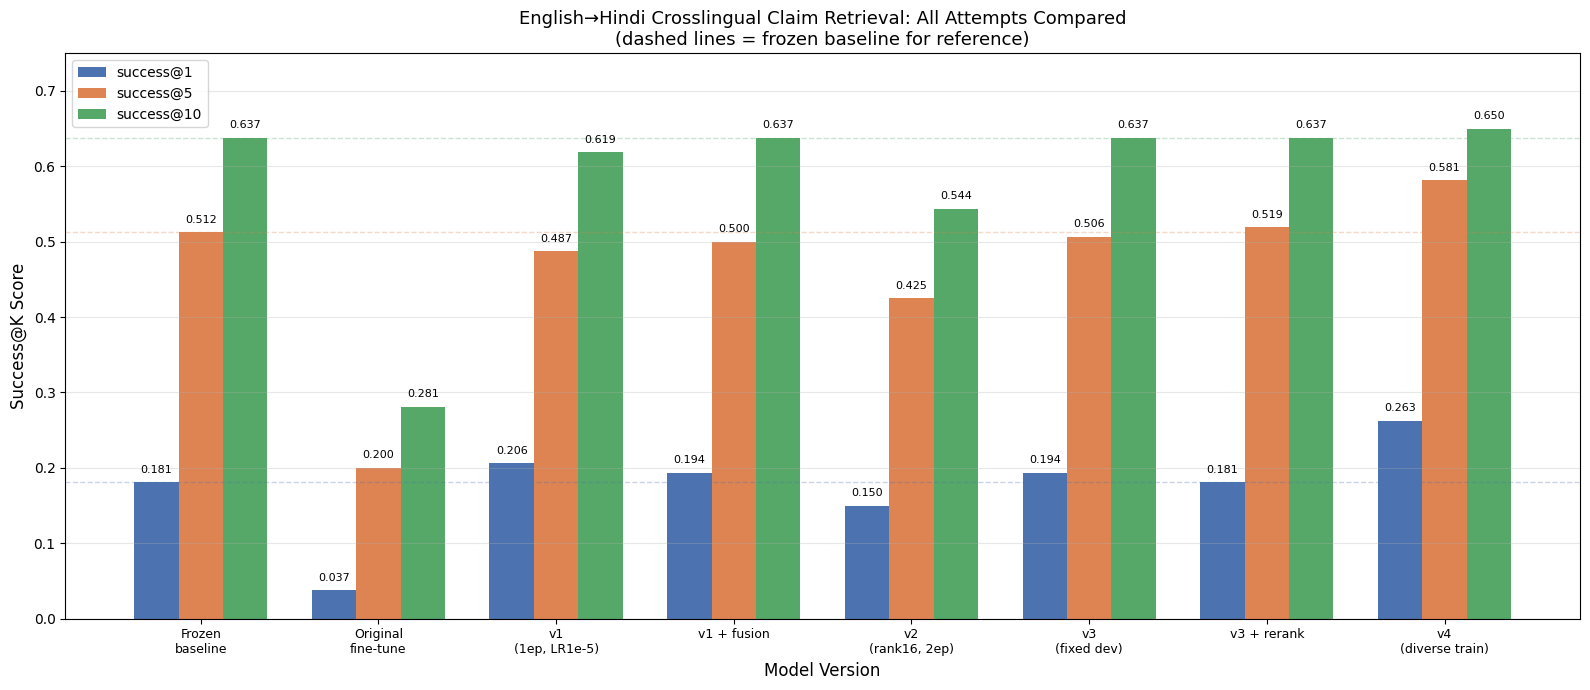

✅ JSON saved to: /content/drive/MyDrive/semeval_eng_hin_crosslingual_results/final_report_visuals/all_versions_results.json
✅ CSV saved to: /content/drive/MyDrive/semeval_eng_hin_crosslingual_results/final_report_visuals/all_versions_results.csv

Final comparison table:
                     success@1  success@5  success@10
version                                              
Frozen\nbaseline        0.1812     0.5125      0.6375
Original\nfine-tune     0.0375     0.2000      0.2812
v1\n(1ep, LR1e-5)       0.2062     0.4875      0.6188
v1 + fusion             0.1938     0.5000      0.6375
v2\n(rank16, 2ep)       0.1500     0.4250      0.5437
v3\n(fixed dev)         0.1938     0.5062      0.6375
v3 + rerank             0.1812     0.5188      0.6375
v4\n(diverse train)     0.2625     0.5813      0.6500


In [17]:
# ============================================================
# VISUALIZATION: Compare all versions across success@1/5/10
# Saves a PNG chart + JSON + CSV of all results to Drive
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import json
import os

# --- All results from this session, hardcoded for reproducibility ---
all_results = {
    'Frozen\nbaseline':        {'success@1': 0.1812, 'success@5': 0.5125, 'success@10': 0.6375},
    'Original\nfine-tune':     {'success@1': 0.0375, 'success@5': 0.2000, 'success@10': 0.2812},
    'v1\n(1ep, LR1e-5)':       {'success@1': 0.2062, 'success@5': 0.4875, 'success@10': 0.6188},
    'v1 + fusion':             {'success@1': 0.1938, 'success@5': 0.5000, 'success@10': 0.6375},
    'v2\n(rank16, 2ep)':       {'success@1': 0.1500, 'success@5': 0.4250, 'success@10': 0.5437},
    'v3\n(fixed dev)':         {'success@1': 0.1938, 'success@5': 0.5062, 'success@10': 0.6375},
    'v3 + rerank':             {'success@1': 0.1812, 'success@5': 0.5188, 'success@10': 0.6375},
    'v4\n(diverse train)':     {'success@1': 0.2625, 'success@5': 0.5813, 'success@10': 0.6500},
}

labels = list(all_results.keys())
metrics = ['success@1', 'success@5', 'success@10']
colors = ['#4C72B0', '#DD8452', '#55A868']

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 7))

for i, metric in enumerate(metrics):
    values = [all_results[l][metric] for l in labels]
    bars = ax.bar(x + i*width - width, values, width, label=metric, color=colors[i])
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, rotation=0)

# Highlight frozen baseline with a horizontal reference line per metric
for i, metric in enumerate(metrics):
    frozen_val = all_results['Frozen\nbaseline'][metric]
    ax.axhline(y=frozen_val, color=colors[i], linestyle='--', alpha=0.3, linewidth=1)

ax.set_xlabel('Model Version', fontsize=12)
ax.set_ylabel('Success@K Score', fontsize=12)
ax.set_title('English→Hindi Crosslingual Claim Retrieval: All Attempts Compared\n(dashed lines = frozen baseline for reference)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.legend(loc='upper left', fontsize=10)
ax.set_ylim(0, 0.75)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

# --- Save everything to Drive ---
viz_output_dir = os.path.join(OUTPUT_DIR, 'final_report_visuals')
os.makedirs(viz_output_dir, exist_ok=True)

fig_path = os.path.join(viz_output_dir, 'all_versions_comparison.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
print(f'✅ Chart saved to: {fig_path}')

plt.show()

# Save raw results as JSON
json_path = os.path.join(viz_output_dir, 'all_versions_results.json')
with open(json_path, 'w') as f:
    json.dump(all_results, f, indent=2, ensure_ascii=False)
print(f'✅ JSON saved to: {json_path}')

# Save as CSV too, for easy import into Sheets/Excel
import pandas as pd
df_results = pd.DataFrame(all_results).T
df_results.index.name = 'version'
csv_path = os.path.join(viz_output_dir, 'all_versions_results.csv')
df_results.to_csv(csv_path)
print(f'✅ CSV saved to: {csv_path}')

print('\nFinal comparison table:')
print(df_results.to_string())